# Tutorial 2: Pandas
-----------------------------------------------
## Overview
NumPy is very fast at handling data. However, it is limited by allowing only ONE data type. Pandas adds the familiar data structure like a spreadsheet, with data organized in rows and columns with names. Why not just use Excel or Sheets, then? Because bioinformatics data sets, such as RNAseq results, are so large and you may need to do complex calculations on the data. Python tools are much faster, more powerful and more flexible than pre-packaged spreadsheet tools. Also, the data is typically not printed to the screen in a GUI interface so the processing speed is faster. If you process in the cloud, you can see substantial increases in speed of analysis.

### Learning Objectives

After this tutorial, you will be able to:
- Define "dataframe"
- Create a Pandas dataframe from scratch or from imported data
- Work with column and rows
- Sort, organize, query, and manipulate the Pandas dataframe
- Visualize pandas dataframes with simple tools
    
### Prerequisites

- Introductory Python
- NumPy (tutorial 2)

### Getting Started
* One way to get introduced to Pandas is provided by pydata: [10 minutes to Pandas](https://pandas.pydata.org/docs/user_guide/10min.html) or their [getting started tutorials](https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html)
* Watch the brief Lecture
* As with NumPy, the custom is to import pandas with the alias of pd to save your typing time.

In [397]:
#Run this code box to install required packages
%pip install jupyterquiz
import pandas as pd
from jupyterquiz import display_quiz
import os
print("All needed tools imported")

Note: you may need to restart the kernel to use updated packages.
All needed tools imported


## Why Pandas?​

The scripting in Python is good till now, but what about data organization or handling columns of tabular data with different types? ​

Pandas focuses on **data management** which can be combined with **analytics tools**​

The core data type is a DataFrame. A DataFrame organizes data into rows and columns, making it easy to access, filter, and process.
![Structure of a Dataframe](pandasDF.png)

You can think of it like an Excel spreadsheet or (more appropriately) like a database table​
  - Tabular​
  - Same data type within Column, but the data type can vary by column​


## Why use DataFrames in Bioinformatics?

In bioinformatics, data often comes in tabular formats, such as gene expression matrices, genomic variant tables, or protein interaction datasets. A Pandas DataFrame provides:

1. Ease of Handling Tabular Data:
    - Rows can represent biological samples, sequences, or variants.
    - Columns can represent genes, features, or metadata.
    - Unlike Excel, Pandas does not attempt to display all the values all the time, so it is less demanding on computer memory-- especially for the large datasets common to bioinformatics

2. Data Analysis: Perform operations like filtering, grouping, and summarizing efficiently.
    - Example: Find the top 10 most expressed genes in RNA-Seq data.

3. Integration: Read/write to biological data formats like CSV, Excel, or SQL.
    - Example: Import genomic data from a CSV file and perform preprocessing.

4. Visualization: Easily integrate with visualization libraries like Matplotlib
    - Example: Plot expression levels of genes across conditions.
    - Since Matplotlib can produce HIGH resolution images, this is a helpful tool for producing publication-ready figures

### Creating Data Frames

A Pandas dataframe can be constructed in many ways. (see [pandas documentation](https://pandas.pydata.org/docs/user_guide/dsintro.html#dataframe) for more ways). Each column is called a **Series** and has it's own functions in Pandas [see more]
We can create a dataframe by passing in a dictionary of equal length lists​

  * The dictionary keys will be column names​

We can also create dataframes from file loads and queries

Here, you see how it is made with a dictionary as the data that you might assemble yourself. 

In [400]:
# Make Dataframe
import pandas as pd 
import numpy as np
np.random.seed(123)
data = {'id': list(range(1,11)),
'yr': list(range(2015,2020))*2,
'count': np.random.randint(10,40,10)}
frame = pd.DataFrame(data)
frame


,id,yr,count
0,1,2015,23
1,2,2016,12
2,3,2017,38
3,4,2018,12
4,5,2019,16
5,6,2015,27
6,7,2016,29
7,8,2017,20
8,9,2018,37
9,10,2019,35


### Importing structured data sets (e.g. CSV)

Probably the most common way to create a Pandas dataframe is to **import a CSV** for further analysis. ​

You can also import excel, JSON, and the clipboard. [All the data types and import methods](http://pandas.pydata.org/pandas-docs/stable/io.html)

Try the next box to import a portion of a large cancer dataset. 

In [544]:
cancer = pd.read_csv(".\Datasets\cancer.csv")
len(cancer)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\jrcha\AppData\Local\Temp\ipykernel_23164\615030498.py:1: SyntaxWarning: invalid escape sequence '\D'
  cancer = pd.read_csv(".\Datasets\cancer.csv")


301

### Another sample dataset: states
Before we tackle bioinformatics datasets, it is customary to work with a toy dataset for which we have some intuition. A dataframe of information about the US states will allow you to learn and practice some Pandas skills.

Can you import the states.csv file from the same folder as cancer? Assign that to the variable states. The code is commented out in the next section, in case you aren't able.

In [ ]:
# Import the states.csv file as a pandas dataframe as states



As soon as we import data, step one should be to check the data import​. Look at the first 3 rows. Showing 5 rows is default, or you can specify with df.head(n=x)


In [551]:
#states = pd.read_csv(".\Datasets\states.csv")
# View
states.head(n=3)
#states.tail()


<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\jrcha\AppData\Local\Temp\ipykernel_23164\1639934536.py:1: SyntaxWarning: invalid escape sequence '\D'
  states = pd.read_csv(".\Datasets\states.csv")


,State,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area
0,Alabama,3615,3624,2.1,69.05,15.1,41.3,20,50708
1,Alaska,365,6315,1.5,69.31,11.3,66.7,152,566432
2,Arizona,2212,4530,1.8,70.55,7.8,58.1,15,113417


## Pandas tools

### Summary Statistics
Are the number of rows as expected? What about the column names? General range of continuous variables? It's easy to asses​s (much more so than with a spreadsheet!!)

A Pandas dataframe has a method (df.describe()) that can easily summarize each column. *The summary information is itself a dataframe*  To get summary statistics on a single column, just specify that with the name in quotes as shown.

Can you obtain these same statistics for the cancer dataset? Note: these values could be meaningful for normalizing gene expression (later tasks)

In [342]:
states.describe()
#states["Murder"].describe()


,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area
count,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000
mean,4246.420000,4435.800000,1.170000,70.878600,7.37800,53.108000,104.460000,70735.880000
std,4464.491433,614.469939,0.609533,1.342394,3.69154,8.076998,51.980848,85327.299622
min,365.000000,3098.000000,0.500000,67.960000,1.40000,37.800000,0.000000,1049.000000
25%,1079.500000,3992.750000,0.625000,70.117500,4.35000,48.050000,66.250000,36985.250000
50%,2838.500000,4519.000000,0.950000,70.675000,6.85000,53.250000,114.500000,54277.000000
75%,4968.500000,4813.500000,1.575000,71.892500,10.67500,59.150000,139.750000,81162.500000
max,21198.000000,6315.000000,2.800000,73.600000,15.10000,67.300000,188.000000,566432.000000


### Rows and Columns 

We also may want to look at just the list of row identifiers (names), or column names. These are stored as attributes of the Pandas dataframe, so we can access the array directly as df.columns or df.index *Though unless reset, the rownames are just a range of numbers*  

**What are the columns in the cancer dataset?**)​


In [420]:
# List Columns
states.columns
# List the row identifiers
#states.index


RangeIndex(start=0, stop=50, step=1)

As with np arrays, you can reference different dimensions.  **df.loc** attribute accesses a group of rows and columns by label(s) or a boolean array in the given DataFrame:
df.loc [:, range] selects a set of columns
df.loc[range,:] selects a set of rows​

Thus, you can subset some rows and some columns based on columns. (next, we'll make a subset based on characteristics like size of the population.)

The code is set up for the states dataframe. Try repeating for columns and/or rows in the cancer dataframe.

In [ ]:
#Take a slice of columns

states.loc[0:8,'Population':'Illiteracy']
#states.loc['Population':'Illiteracy']
#states.loc[3:7,:]
#states[3:7]


### Test your knowledge
*run the next box for a quiz*

In [389]:
import os
from jupyterquiz import display_quiz
indqz = "." + os.sep + "PythonQuizQuestions" + os.sep + "pandas_index.json"
display_quiz(indqz)

<IPython.core.display.Javascript object>

### Indexes

We can select portions of the data fram by indexes (rows and columns) in a variety of ways (some of which may seem inconsistent.) ​

In [346]:
# Indexing
# Select Column
states['State']
# Or select more than one column
#states[['Area', 'State']]
 
# By column name attribute
states.State[0:6]

0       Alabama
1        Alaska
2       Arizona
3      Arkansas
4    California
5      Colorado
Name: State, dtype: object

In [347]:
# Indexing
# Or select more than one column
states[['Area', 'State']]
 
# By column name attribute
states.State[0:6]

0       Alabama
1        Alaska
2       Arizona
3      Arkansas
4    California
5      Colorado
Name: State, dtype: object

In [348]:
# Indexing
# Or by row, which is technically an attribute of the column data
states.State[0:6]

0       Alabama
1        Alaska
2       Arizona
3      Arkansas
4    California
5      Colorado
Name: State, dtype: object

In [349]:
# Select Row (labels, index)
states[0:2]


,State,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area
0,Alabama,3615,3624,2.1,69.05,15.1,41.3,20,50708
1,Alaska,365,6315,1.5,69.31,11.3,66.7,152,566432


We can also index with **boolean​s**. We've shown how to select for states. 

Can you select for genes with a minimal level of expression across all the samples? across some of the samples? 

In [351]:
# select by boolean characteristics
states[states.Murder <= 2.7]


,State,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area
14,Iowa,2861,4628,0.5,72.56,2.3,59.0,140,55941
18,Maine,1058,3694,0.7,70.39,2.7,54.7,161,30920
22,Minnesota,3921,4675,0.6,72.96,2.3,57.6,160,79289
33,North Dakota,637,5087,0.8,72.78,1.4,50.3,186,69273
38,Rhode Island,931,4558,1.3,71.90,2.4,46.4,127,1049
40,South Dakota,681,4167,0.5,72.08,1.7,53.3,172,75955


## Test your Knowledge
> 1. Efficiently determine how many states have a life expectancy between 70 and 71
> 2. What is the average HS Graduate percentage for these states?

In [353]:
#Run this code box for a quiz
from jupyterquiz import display_quiz
import os
lenqz= "." + os.sep + "PythonQuizQuestions" + os.sep + "pd_boolean_lengthQz.json"

display_quiz(lenqz)

<IPython.core.display.Javascript object>

In [354]:
#Answers
x=states.loc[(states['Life Exp']>71) & (states['Life Exp']>70)]
len(x)
#x['HS Grad'].mean()


20

In [355]:
# select by integer location
states.iloc[0:3,0:4] #not end inclusive
 
# select by label only
states.loc[0:15,"Population":"Life Exp"]
# end inclusive



,Population,Income,Illiteracy,Life Exp
0,3615,3624,2.1,69.05
1,365,6315,1.5,69.31
2,2212,4530,1.8,70.55
3,2110,3378,1.9,70.66
4,21198,5114,1.1,71.71
5,2541,4884,0.7,72.06
6,3100,5348,1.1,72.48
7,579,4809,0.9,70.06
8,8277,4815,1.3,70.66
9,4931,4091,2.0,68.54


### Adding/Deleting columns

We can add columns by naming a new column, then assigning a set of values​. If the added column doesn't have enough values, Pandas will automatically add NaN

Use the **del** keyword to delete a column​

<p style="background:green;color:white;font-family:arial"> Try this: You might have noticed that the first two columns of the cancer dataset are basically the same. Drop one of them & check the head to show you were successful.</p>

In [555]:
# Add Column
states["NewCol"] = 4
states.head()
 
# Delete Column
#del states["NewCol"]
#states.head()

,State,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area
0,Alabama,3615,3624,2.1,69.05,15.1,41.3,20,50708
1,Alaska,365,6315,1.5,69.31,11.3,66.7,152,566432
2,Arizona,2212,4530,1.8,70.55,7.8,58.1,15,113417
3,Arkansas,2110,3378,1.9,70.66,10.1,39.9,65,51945
4,California,21198,5114,1.1,71.71,10.3,62.6,20,156361


### Adding/deleting rows
​
The syntax is slightly more complex to add a row to a Pandas dataframe. 

You can make a new row, then **concat**, that is to concatenate the data. This row should be a single dictionary for one row, or multiple dictionaries to add multiple rows. Since it's a dictionary, you don't have to put the data in the 'correct' order of the existing dataframe. 

new_row= pd.DataFrame(\[{key:value, key1:value1, key2:value2}]

If you do not give a value for each of the columns, then Pandas will use NaN

Then, add that row of new data by concatenation. 
df = pd.concat(\[df, new_rows], ignore_index=True)

**To delete**, and to directly replace the dataframe using the inplace tag:

df.drop(index=\[Rowindex1, Rowindex2], inplace=True)

If you just drop one row, use index=#

In [588]:
# Add one or more Rows by Concatenation

new_states = pd.DataFrame([{'State':'Puerto Rico', 'Population':'3242','Murder':'17.2'},{'State':'US VI', 'Population':'0.41','Murder':'40', 'HS Grad':'78'}])
states = pd.concat([states, new_states], ignore_index=True)

states.tail()

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\jrcha\AppData\Local\Temp\ipykernel_23164\995002204.py:2: SyntaxWarning: invalid escape sequence '\D'
  states = pd.read_csv(".\Datasets\states.csv")


,State,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area
47,West Virginia,1799,3617.0,1.4,69.48,6.7,41.6,100.0,24070.0
48,Wisconsin,4589,4468.0,0.7,72.48,3.0,54.5,149.0,54464.0
49,Wyoming,376,4566.0,0.6,70.29,6.9,62.9,173.0,97203.0
50,Puerto Rico,3242,NaN,NaN,NaN,17.2,NaN,NaN,NaN
51,US VI,0.41,NaN,NaN,NaN,40,78,NaN,NaN


Now, remove Puerto Rico row, with df.drop, using its index & check the tail

In [590]:
states.drop(index=50, inplace=True)
states.tail()

,State,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area
46,Washington,3559,4864.0,0.6,71.72,4.3,63.5,32.0,66570.0
47,West Virginia,1799,3617.0,1.4,69.48,6.7,41.6,100.0,24070.0
48,Wisconsin,4589,4468.0,0.7,72.48,3.0,54.5,149.0,54464.0
49,Wyoming,376,4566.0,0.6,70.29,6.9,62.9,173.0,97203.0
51,US VI,0.41,NaN,NaN,NaN,40,78,NaN,NaN


### Reindexing After Subsetting
Did you notice that while Pandas automatically adds the correct row index when concatenating, it does NOT automatically renumber or 'reindex'

You can use that to your advantage (remembering that US VI will always be index 51) or we can reindex:

**df.reset_index(drop=True, inplace=True)**

If you take a subset of a dataframe (see next code box), you can see why reindexing would be important afterwards since this is not done automatically post subset.​

In [608]:
#After changing states, it might help to make a clean copy again by removing the comment from the next line
#states = pd.read_csv(".\Datasets\states.csv")
states_sub = states[states.Population < 1000]

# Reindex
#states_sub.reset_index(drop=True, inplace=True)  # you are dropping the column index which Pandas creates to "remember" the original index

states_sub

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\jrcha\AppData\Local\Temp\ipykernel_23164\1537616322.py:2: SyntaxWarning: invalid escape sequence '\D'
  states = pd.read_csv(".\Datasets\states.csv")


,State,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area
0,Alaska,365,6315,1.5,69.31,11.3,66.7,152,566432
1,Delaware,579,4809,0.9,70.06,6.2,54.6,103,1982
2,Hawaii,868,4963,1.9,73.60,6.2,61.9,0,6425
3,Idaho,813,4119,0.6,71.87,5.3,59.5,126,82677
4,Montana,746,4347,0.6,70.56,5.0,59.2,155,145587
5,Nevada,590,5149,0.5,69.03,11.5,65.2,188,109889
6,New Hampshire,812,4281,0.7,71.23,3.3,57.6,174,9027
7,North Dakota,637,5087,0.8,72.78,1.4,50.3,186,69273
8,Rhode Island,931,4558,1.3,71.90,2.4,46.4,127,1049
9,South Dakota,681,4167,0.5,72.08,1.7,53.3,172,75955


## Dealing with Missing Values 

Pandas uses NaN to cover missing values​. You saw that when we added rows that did not give all the key:value pairs for every column.

This may occur for many reasons in bioinformatics:
1. A log2 fold-change might be NaN if the raw counts for a gene are zero in both conditions
2. In multiple sequence alignments (MSAs), some positions may lack data for certain sequences due to indels or incomplete sequence coverage. After processing such data into a DataFrame, these gaps may appear as NaN.
3. Combining datasets with mismatched identifiers or incomplete overlap of genes, samples, or annotations can introduce NaN values. For instance, merging a gene annotation file with an expression matrix may leave gaps for genes without annotations.
4. RNA-seq data may lack expression levels for some genes in certain samples due to low expression or poor sequencing depth.

You can drop a row (or col) that has missing data with **df.dropna(inplace=True)**    

You can fill missing values in with **df.fillna(#, inplace=True)**

- Why? for example for count data (e.g., RNA-seq), NaN might mean **no reads** were mapped, so replacing with *0* makes sense.

This will depend on your **knowledge** of the system and what NaN means or does not for your particular dataset.

(the first few lines of code just add a few NaNs to a copy of the states dataframe & illustrates a clever use of the original.

You can go back to the section above and perform these cleanups on our States dataframe with Puerto Rico and the US Virgin Islands for practice. 

In [472]:
# Creating a dataset with missing Data
states_miss  = states.copy() #so we can work with a separate copy
# Set all Population values below 1000 to missing, NaN, using the locations in the initial states dataframe
states_miss.Population[states.Population < 1000] = np.NaN

# Now, drop missing data
#states_miss.dropna(inplace=True)                       #drops any row that has NaN 
#states_miss.fillna(0, inplace=True)
states_miss.loc[0:15,["State","Population"]]

#to drop the column with NaN in it
#states_miss.dropna(axis=1, inplace=True)               # The only column with NaN is Population, which will be dropped from the states_miss dataframe
#states_miss.head()

C:\Users\jrcha\AppData\Local\Temp\ipykernel_23164\3627217014.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  states_miss.Population[states.Population < 1000] = np.NaN
C:\Users\jrcha\AppData\Local\Temp\ipykernel_23164\3627217014.py:4: Set

,State,Population
0,Alabama,3615.0
1,Alaska,NaN
2,Arizona,2212.0
3,Arkansas,2110.0
4,California,21198.0
5,Colorado,2541.0
6,Connecticut,3100.0
7,Delaware,NaN
8,Florida,8277.0
9,Georgia,4931.0


We use **.isnull()** and **.notnull()** to check for missing values, with a resulting dataframe of True and False values​


In [484]:
#recreate the states_miss dataframe with missing values
states_miss  = states.copy() #so we can work with a separate copy
states_miss.Population[states.Population < 1000] = np.NaN
# isnull
states_miss.isnull()
#states_miss.notnull()

#cancer.isnull()

C:\Users\jrcha\AppData\Local\Temp\ipykernel_23164\3071454608.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  states_miss.Population[states.Population < 1000] = np.NaN
C:\Users\jrcha\AppData\Local\Temp\ipykernel_23164\3071454608.py:3: Set

,Gene Description,Gene Accession Number,1,2,3,4,5,6,7,8,...,35,36,37,38,28,29,30,31,32,33
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
299,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Data wrangling

A large challenge when working with real biological datasets is data "cleaning." This removes values or samples with errors (negative read counts, participants over age 110) or missing data (NaN) that could skew downstream analysis. This process must be carried out systematically and carefully. The normal workflow for this is beyond this introductory module. Please look at _____ for a full treatment.

You've already seen how to remover NaN. It is also straight-forward to remove duplicated data.

### Removing Duplicates</div> 

Duplicates in a Pandas DataFrame can be problematic for several reasons, depending on the context of your analysis or data manipulation.

It might mean
1. Data Integrity Issues
2. Increased Storage and Processing
3. Impact on Data Validation
4. Issues with Data Joins or Merges
5. Reduced Data Quality
6. Challenges in Machine Learning

Fortunately, Pandas has a simple way to manage these: 

- df.duplicated(): <u>Identifies</u> duplicate rows.
- df.drop_duplicates(): <u>Removes</u> duplicate rows.</u>
- df.duplicated(subset=\[...]): Checks for duplicates in <u>specific columns</u> only.

In [644]:
# Duplicates

df_dup  = df.append(df.iloc[1]) # this adds the smame row twice

df_dup.duplicated()

#df_dup.drop_duplicates()

AttributeError: 'DataFrame' object has no attribute 'append'

## Running functions on dataframes

Remembr that an advantage of using Pandas dataframes can streamline operations because they are built on top of NumPy, leveraging its efficient array processing capabilities, and they incorporate metadata (row/column labels, data types) that allow automatic alignment, indexing, and optimized handling of structured tabular data.

Functions can operate in two basic ways on a dataframe. 

- Data Reduction: Functions which reduce a list of inputs to 1 output (e.g., the results in the 'describe' function like mean and max).
     - These, by default, operate on the **column** ​
- "Element-wise": Functions which return one output result for each input operate on the dataframe element-by-element.
     -  df.applymap(lambda x: x\**2)    *to divide ALL values in df by 2*
     -  specify a column df\[column].apply(lambda x: x+2) *to add 2 to specific columns*
     -  round elements with df.round(2)​
 
We'll recall our first dataframe above (called frame) which has only integers to demonstrate a few functions on the whole dataframe

Note: lambda is a way to skip defining a function when we just need to do something function-like quickly

The subsequent boxes illustrate mean

In [696]:
# Functions on DataFrames
frame.mean()
#cancer["2"].mean()
#result=states["Population"].apply(lambda x: x/1000)

#result.mean()

946.873754152824

In [684]:
# More Functions on DataFrames
 
# Returning More than One Value
states_copy = states.copy()
states_copy[["Population", "Illiteracy"]]=states_copy[["Population", "Illiteracy"]].diff()
states_copy.head()         #since there was nothing to subtract the first row of population & illiteracy frome, theose 

,State,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area
0,Alabama,NaN,3624,NaN,69.05,15.1,41.3,20,50708
1,Alaska,-3250.0,6315,-0.6,69.31,11.3,66.7,152,566432
2,Arizona,1847.0,4530,0.3,70.55,7.8,58.1,15,113417
3,Arkansas,-102.0,3378,0.1,70.66,10.1,39.9,65,51945
4,California,19088.0,5114,-0.8,71.71,10.3,62.6,20,156361


Doing an element-wise operation is the same as our original notion of vectorization​

Note in the sample here we are combining a table-wise and element-wise operation as a comparison​

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame(np.random.randn(5,3),columns=['col1','col2','col3'])
print(df.apply(np.mean))    # old mean
print(df.applymap(lambda x:x*100)) # modify elements
print(df.applymap(lambda x:x*100).apply(np.mean)) # new mean

### Sorting a DF 

We use **.sort_values()** to sort a data frame​

We can sort by either the index or a column(s)​

In [ ]:
# Sorting
states.sort_values("Population")
states.sort_values("Population“, ascending=True)

# Multiple sorts
states.sort_values(by=["Illiteracy","Population"]) states.sort_values(by=["Illiteracy","Population"],
ascending=[True,False])

Iterating over a series (1d) object is similar to an array or tuple​

Iterating over a dataframe or panel is a little trickier​

The iteration for them provides a dictionary object which has the columns/values of rows/values​

  - Use items() for column-wise​

  - Use iterrows() for row-wise​
  
The **iteritems()** method produces key, value pairs with the column name and the column values as a series​

In [640]:
df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})

for key, value in df.items():
    print(key,"   ", value)

#for key, value in df.iterrows():
#    print(key,"   ", value)

A     0    1
1    2
2    3
Name: A, dtype: int64
B     0    4
1    5
2    6
Name: B, dtype: int64


### Unique Values

We can use the .unique() function of Series to Get unique values from a column​

Use the sorted function to sort the output from unique

In [ ]:
# Unique Values
states["Illiteracy"].unique()

# Unique Values from data set
states.drop_duplicates()

## Merge

It might be useful to merge two dataframes together.  You need to picture them & ask yourself how they should be arranged- which of the 2 on the left & which on the right. 

To merge them together, we can use the **pd.merge()** function & specify "where" each one goes. See the syntax below.

In [ ]:
# Import Dataframe
states = pd.read_csv(r"C:\data\states.csv")
states2 = pd.read_csv(r"C:\data\states_extra.csv")

# Merge these together
pd.merge(states,states2,how="left", left_on="State",right_on=“ST")

## Working with Text 

Strings in Pandas are roughly the same as strings in Python​

We simply operate on series rather than a single object​

Pandas provides many of the same methods, such as **len()**, **lower()**, **upper()**, **split()** and others you have seen before​

Pandas methods also usually ignore missing NaN values​

In [ ]:
s = pd.Series(['Tom', 'William Rick', 'John', 'Alber@t'
               , np.nan, '1234','SteveSmith'])

print(s)
print(s.str.lower())
print(s.str.upper())
print(s.str.len())

## Reshaping 

You may need to reshape a DataFrame in Pandas for bioinformatics problems because biological data often comes in complex formats that require adjustments to perform specific analyses. For example:

1. Gene Expression Analysis: Reshaping is needed to pivot wide-form data (genes as columns) into long-form (genes as rows) for statistical modeling. 
2. Sequence Data: Transposing or reorganizing DataFrames allows better alignment of sequences (e.g., rows for samples, columns for nucleotides or amino acids).
3. Multi-dimensional Data: Reshaping helps process hierarchical datasets (e.g., patients, samples, and measurements) by summarizing or splitting relevant portions.
4. Comparative Analysis: To calculate differences or correlations, specific subsets of data (like df\[\['A', 'B']].diff()) may need reshaping to focus on sequential or paired comparisons.

Essentially, reshaping can ensure that data aligns with the structure required by bioinformatics algorithms.

The easiest change is **transforming** from rows to columns: df.T
The code box shows how to transform AND to make the column names the sample information rather than row count.

In [726]:
# Transposing a dataframe
# Example DataFrame
df = pd.DataFrame({
    'Sample': ['A', 'B', 'C'],
    'Gene1': [5.1, 4.8, 6.2],
    'Gene2': [7.3, 6.9, 8.0]
})
print(df)
# Transpose the DataFrame

#print( df.set_index('Sample').T)


  Sample  Gene1  Gene2
0      A    5.1    7.3
1      B    4.8    6.9
2      C    6.2    8.0


#### Reshaping from Long to Wide 

Scenario: You have experimental data where each sample is measured under multiple conditions, the data is in a long format.
 Sample  Condition  Measurement
0      A    Control          5.1
1      A  Treatment          7.2
2      B    Control          4.8
3      B  Treatment          6.9
4      C    Control          5.9
5      C  Treatment          8.1

We need to reshape the data so that each *condition* becomes a *column*:

In [740]:
import pandas as pd

data=pd.DataFrame({'Sample': ['A', 'A', 'B', 'B', 'C', 'C'], 'Condition': ['Control', 'Treatment', 'Control', 'Treatment', 'Control', 'Treatment'],'Measurement': [5.1, 7.2, 4.8, 6.9, 5.9, 8.1]})
data

,Sample,Condition,Measurement
0,A,Control,5.1
1,A,Treatment,7.2
2,B,Control,4.8
3,B,Treatment,6.9
4,C,Control,5.9
5,C,Treatment,8.1


In [742]:
# Reshape to wide format
wide_df = data.pivot(index='Sample', columns='Condition', values='Measurement')
wide_df

Condition,Control,Treatment
Sample,,
A,5.1,7.2
B,4.8,6.9
C,5.9,8.1


#### Reshaping from Wide to Long

If you start with data in wide format and need to convert it back to long format:

In [744]:
long_df = wide_df.reset_index().melt(id_vars='Sample', var_name='Condition', value_name='Measurement')
long_df

,Sample,Condition,Measurement
0,A,Control,5.1
1,B,Control,4.8
2,C,Control,5.9
3,A,Treatment,7.2
4,B,Treatment,6.9
5,C,Treatment,8.1


### Making categories 

It might be that you need to divide your data into groups. For example, if you have a patient data set with the exact values of their temperatures, but you really just need to know "normal, fever, severe fever" as categories. Here we can show it this, too, with our states data. ​

We can use **df.cut()**

You describe the bins (this process can be called "binning") and assign names to the categories. 

In [764]:
# binning with cut
states.Population.describe()
bins = [0,1000,3000,5000,25000]
pd.cut(states.Population, bins)

# With Labels
states['Population_cat']= pd.cut(states.Population, bins, labels=["small","med","large","huge"]) #adds a new column with these bins
states.head()


,State,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area,Population_cat
0,Alabama,3615,3624,2.1,69.05,15.1,41.3,20,50708,large
1,Alaska,365,6315,1.5,69.31,11.3,66.7,152,566432,small
2,Arizona,2212,4530,1.8,70.55,7.8,58.1,15,113417,med
3,Arkansas,2110,3378,1.9,70.66,10.1,39.9,65,51945,med
4,California,21198,5114,1.1,71.71,10.3,62.6,20,156361,huge


We often want to apply functions to groups within our dataset. ​

  - What is the mean value within group?​

  - What is the variance within group?​

  - Perform a linear regression within group, then get the slope estimates out.​

The first step is to establish the groups (SPLIT)​

In Pandas, we can use the **.groupby()** method for this​

Use states, and group on the variable we just created ​

In [792]:
# Group by 'Category' and calculate mean
result = states.groupby('Population_cat', observed=True)['HS Grad'].mean()
result

# Group by 'Category' and calculate both mean and sum of income within the category
#result2 = states.groupby('Population_cat', observed=True)['Income'].agg(['mean', 'sum'])
#result2

Population_cat
small    57.891667
med      53.521429
large    48.741667
huge     52.208333
Name: HS Grad, dtype: float64

We can index the group-by with a dynamically created value

In [794]:
# Group By Dynamic Variables
states.Illiteracy.groupby(states.Income < 4100).mean()

Income
False    0.951429
True     1.680000
Name: Illiteracy, dtype: float64

<div style="font-size:18px">Cross Tabs</div>

Frequency Table

Classic statistical aggregation. How many observations occupy each group? 

In [ ]:
# Cross Tabs 
pd.crosstab(states.Income < 4100,states. Population_cat) 
pd.crosstab(states.Income < 4100,states. Population_cat,margins=True) 

<div style="font-size:18px">Applying Functions</div> 

How could we get the percentages rather than the frequencies?​

We can apply a function across rows or columns using **pd.apply()**

In [ ]:
# Create the table
tbl1 = pd.crosstab(states.Income < 4100,states.Population_cat)

# Applying Functions
tbl1.apply(lambda x: x/x.sum(),axis=0)
tbl1.apply(lambda x: x/x.sum(),axis=1)

## Basic Statistics with Pandas
Because we do a lot of data analytics with Pandas, it’s good to know some statistics​

  - Pandas supports all the basics​

  - Mean, median, mode, min, max​

  - Covariance, Correlation, Ranking

In [ ]:
s = pd.Series([1,2,3,4,5,4])
print(s.pct_change())
print(s.cov(s2))

df = pd.DataFrame(np.random.randn(5, 2))
print(df.pct_change())
print(df.mean())
print(df.median(axis=1))
print(df.mode(axis=1))

### Correlation

Correlation shows the linear relationship between two series​

There are multiple ways to compute the correlation like Pearson (default), Spearman and Kendall​

Correlate a pair of rows or the entire dataframe​

In [832]:
import pandas as pd

# A small gene expression DataFrame
data = pd.DataFrame({'Sample': ['Sample1', 'Sample2', 'Sample3'],
    'Gene1': [5.3, 4.8, 5.9],
    'Gene2': [7.1, 6.8, 8.3],
    'Condition': ['Control', 'Treatment', 'Control']})
data
# Calculate correlation between Gene1 and Gene2
print(data[['Gene1', 'Gene2']].corr())

          Gene1     Gene2
Gene1  1.000000  0.960769
Gene2  0.960769  1.000000


In [836]:
# Filter the DataFrame for Control samples
control_df = data[data['Condition'] == 'Control']

# Calculate correlation between Gene1 and Gene2 for Control samples
control_correlation = control_df[['Gene1', 'Gene2']].corr()
print(control_correlation)

       Gene1  Gene2
Gene1    1.0    1.0
Gene2    1.0    1.0


## Pandas Visuals 

We have a whole section on visuals (mainly using matplotlib), but because it is so important to data analytics, pandas provides visuals too​

Pandas supports many types of plots​

  - Line, bar, area, box, histogram and scatter plots among others

<Axes: >

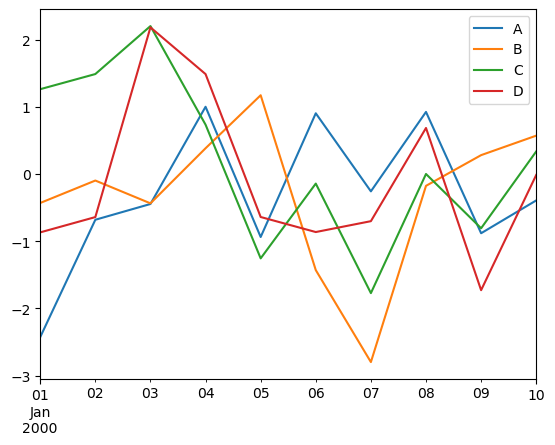

In [646]:
df = pd.DataFrame(np.random.randn(10,4),
        index=pd.date_range('1/1/2000',
        periods=10), columns=list('ABCD'))

df.plot()

In [ ]:
df = pd.DataFrame(np.random.rand(10,4),
        columns=['a','b','c','d'])
df.plot.bar()

In [ ]:
# stacked bar
df.plot.bar(stacked=True)

In [ ]:
# horizontal stacked bar
df.plot.barh(stacked=True)

In [ ]:
df = pd.DataFrame({'a':np.random.randn(1000)+1
                   ,'b':np.random.randn(1000),'c':
np.random.randn(1000) - 1}, columns=['a', 'b', 'c'])
# histogram
df.plot.hist(bins=20)

In [ ]:
df = pd.DataFrame(np.random.rand(50, 4)
    , columns=['a', 'b', 'c', 'd'])
df.plot.scatter(x='c', y='b')
df.plot.box()

In [ ]:
df = pd.DataFrame(3 * np.random.rand(4)
    , index=['a', 'b', 'c', 'd'], columns=['x'])
df.plot.pie(subplots=True)

Time for some bioinformatics exercises!

# Test Your Knowledge

Create a function to:

> 1. Take an array as input (from a data frame)
> 2. Output the mean, median, and a sorted list of unique values

# Conclusion
You now have tools to do a LOT of manipulations of data frames with Pandas in Python. You are ready for a bioinformatics exercise.
1. **Completely solved** Exploring ligand binding sites in a pdb file (protein structure file) using pandas and biopandas
2. **Guided exercise** with an RNA seq dataset

If you do not want to practice at this point, the next tutorial picks up with how to [visualize your data](./Submodule_2_Tutorial3_VisualizingData.ipynb) with graphs in matplotlib


## Clean up
Remember to stop your Jupyter Notebook compute instance to avoid unnecessary charges..